<a href="https://colab.research.google.com/github/ethanboyjeff/ELE2038-Coursework/blob/main/ELE2038_CW_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 27.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import control as ctrl
from scipy.signal import StateSpace, lsim, TransferFunction

# Modelling

# defining variable symbols

In [ ]:
m, g, d, delta, r, R, L0, L1, alpha, c, k, b, phi, i, Km, tau_m = sym.symbols('m, g, d, \\delta, r, R, L0, L1, \\alpha, c, k, b, \\phi, i, K_m, \\tau_m', positive = True)
x1, x2, x3, u = sym.symbols('x_1, x_2, x_3, u', real = True)

# state space

input is u=V

In [ ]:
x1_dot = x2
x1_dot

x_2

In [ ]:
x2_dot = (5/(7*m))*(m*g*sym.sin(phi)+(c*(x3**2)/(delta-x1)**2)-k*(x1-d)-b*x2)
x2_dot

5*(-b*x_2 + c*x_3**2/(\delta - x_1)**2 + g*m*sin(\phi) - k*(-d + x_1))/(7*m)

In [ ]:
x3_dot = (u-x3*R)/(L0+L1*sym.exp(-alpha*(delta-x1)))
x3_dot

(-R*x_3 + u)/(L0 + L1*exp(-\alpha*(\delta - x_1)))

# Linearisation

Sub in equilibrium points $(x_1^e, x_2^e, x_3^e, u^e)$ and make the 3 equations equal to zero.

Then subtract by parts and define non-linear parts as follows:

$β(x_1, x_2, x_3) = \frac{5}{7m}(mgsin(ϕ) + \frac{c(x_3)^2}{(δ-x_1)^2} - k(x_1-d)-bx_2)$

In [ ]:
beta = (5/(7*m))*(m*g*sym.sin(phi)+(c*(x3**2)/(delta-x1)**2)-k*(x1-d)-b*x2)
beta

5*(-b*x_2 + c*x_3**2/(\delta - x_1)**2 + g*m*sin(\phi) - k*(-d + x_1))/(7*m)

$γ(x_1, x_3, u) = \frac{u-x_3R}{L_0 + L_1exp(-α(δ-x_1))}$

In [ ]:
gamma = (u-x3*R)/(L0+L1*sym.exp(-alpha*(delta-x1)))
gamma

(-R*x_3 + u)/(L0 + L1*exp(-\alpha*(\delta - x_1)))

Linearise β at equilibrium point $(x_1^e, x_2^e, x_3^e)$

In [ ]:
x1e, x2e, x3e, ue = sym.symbols('x_1^e, x_2^e, x_3^e, u^e', positive = True)

In [ ]:
beta_x1 = sym.diff(beta, x1).subs([(x1, x1e), (x2, x2e), (x3, x3e)])
beta_x1

5*(2*c*x_3^e**2/(\delta - x_1^e)**3 - k)/(7*m)

In [ ]:
beta_x2 = sym.diff(beta, x2).subs([(x1, x1e), (x2, x2e), (x3, x3e)])
beta_x2

-5*b/(7*m)

In [ ]:
beta_x3 = sym.diff(beta, x3).subs([(x1, x1e), (x2, x2e), (x3, x3e)])
beta_x3

10*c*x_3^e/(7*m*(\delta - x_1^e)**2)

linearise γ at equilibrium point $(x_1^e, x_3^e, u^e)$

In [ ]:
gamma_x1 = sym.diff(gamma, x1).subs([(x1, x1e), (x3, x3e), (u, ue)])
gamma_x1

-L1*\alpha*(-R*x_3^e + u^e)*exp(-\alpha*(\delta - x_1^e))/(L0 + L1*exp(-\alpha*(\delta - x_1^e)))**2

In [ ]:
gamma_x3 = sym.diff(gamma, x3).subs([(x1, x1e), (x3, x3e), (u, ue)])
gamma_x3

-R/(L0 + L1*exp(-\alpha*(\delta - x_1^e)))

In [ ]:
gamma_u = sym.diff(gamma, u).subs([(x1, x1e), (x3, x3e), (u, ue)])
gamma_u

1/(L0 + L1*exp(-\alpha*(\delta - x_1^e)))

deviation variables:

$ubar = u - u^e$

$x_1bar = x_1 - x_1^e$

$x_2bar = x_2 - x_2^e$

$x_3bar = x_3 - x_3^e$

In [ ]:
x1bar, x2bar, x3bar, ubar = sym.symbols('xbar_1, xbar_2, xbar_3, ubar', positive = True)

final linear equations:

In [ ]:
x1bar_dot = x2bar
x1bar_dot

xbar_2

In [ ]:
x2bar_dot = beta_x1*x1bar + beta_x2*x2bar + beta_x3*x3bar
x2bar_dot

-5*b*xbar_2/(7*m) + 10*c*x_3^e*xbar_3/(7*m*(\delta - x_1^e)**2) + 5*xbar_1*(2*c*x_3^e**2/(\delta - x_1^e)**3 - k)/(7*m)

In [ ]:
x3bar_dot = gamma_x1*x1bar + gamma_x3*x3bar + gamma_u*ubar
x3bar_dot

-L1*\alpha*xbar_1*(-R*x_3^e + u^e)*exp(-\alpha*(\delta - x_1^e))/(L0 + L1*exp(-\alpha*(\delta - x_1^e)))**2 - R*xbar_3/(L0 + L1*exp(-\alpha*(\delta - x_1^e))) + ubar/(L0 + L1*exp(-\alpha*(\delta - x_1^e)))

System parameters

In [ ]:
#system parameters
m = 0.462
g = 9.81
d = 0.42
delta = 0.65
r = 0.123
R = 2200
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c = 6.811
k = 1885
b = 10.4
phi = np.deg2rad(41)
tau_m = 0.03
Km = 1 #assumed

Equilibrium around step point $x_sp$

In [ ]:
#at equilibrium
isp, usp = sym.symbols('i_sp, u_sp', positive = True)
x1e = x_sp = 0.5
x2e = 0
x3e = isp
ue = usp

working out $i_{sp}$

In [ ]:
i_sp = np.sqrt((1/c)*((delta - x_sp)**2)*(k*(x_sp-d)-m*g*np.sin(phi)))
print(i_sp)

0.698814821219778


working out $u_{sp}$

In [ ]:
u_sp = i_sp * R
print(u_sp)

1537.3926066835115


# Non-linear IVP simulation

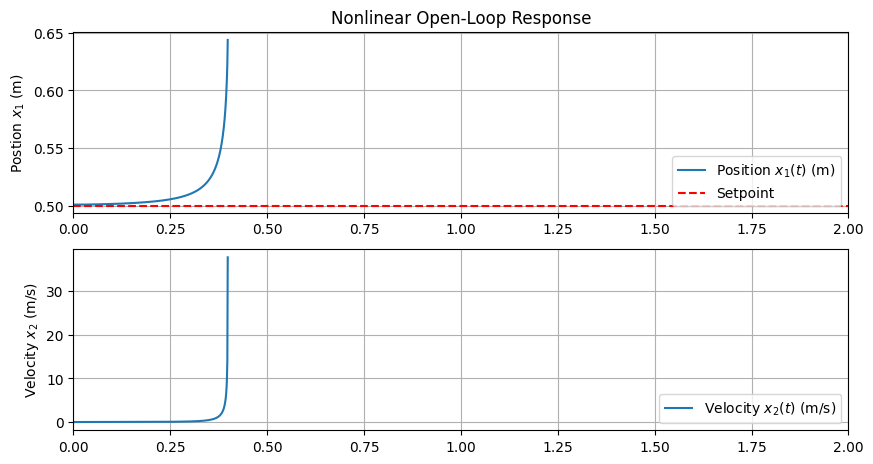

In [ ]:
#assuming inital values are equilibrium from linearised system
x_sp = 0.5
u_sp = 1537.3926066835115

def system_dynamics(t, state, u):
  x1, x2, x3 = state

  x1_dot = x2
  x2_dot = (5/(7*m))*(m*g*sym.sin(phi)+(c*(x3**2)/(delta-x1)**2)-k*(x1-d)-b*x2)
  x3_dot = (u-x3*R)/(L0+L1*sym.exp(-alpha*(delta-x1)))

  return [x1_dot, x2_dot, x3_dot]

t_span = [0, 2]
#1mm disturbance to equilibrium
state0 = [x_sp+0.001, 0, i_sp]
t_eval = np.linspace(0, 2, 2000)

sol = solve_ivp(system_dynamics, t_span, state0, t_eval=t_eval, args=(u_sp,))

plt.figure(figsize=(10, 8))

#position subplot
plt.subplot(3, 1, 1)
plt.plot(sol.t, sol.y[0], label='Position $x_1(t)$ (m)')
plt.axhline(y=x_sp, color='r', linestyle='--', label='Setpoint')
plt.ylabel('Postion $x_1$ (m)')
plt.title('Nonlinear Open-Loop Response')
plt.xlim(0, 2.0)
plt.legend(loc = 'lower right')
plt.grid(True)

#velocity subplot
plt.subplot(3, 1, 2)
plt.plot(sol.t, sol.y[1], label='Velocity $x_2(t)$ (m/s)')
plt.ylabel('Velocity $x_2$ (m/s)')
plt.xlim(0, 2.0)
plt.grid(True)

plt.legend(loc = 'lower right')
#current
#plt.subplot(3, 1, 3)
#plt.plot(sol.t, sol.y[2], label='Current $x_3(t)$')
#plt.xlabel('Time (t)')
#plt.ylabel('Current (x_3)')
#plt.xlim(0, 2.0)
#plt.grid(True)

plt.show()

# Laplace of linearised equations


*   $sX_1bar(s) = X_2bar(s)$

*   $sX_2bar(s) = AX_1bar(s) + BX_2bar(s) + CX_3bar(s)$

*   $sX_3bar(s) = DX_1bar(s) + EX_3bar(s) + FUbar(s)$




open-loop transfer function is $\frac{X_1bar(s)}{Ubar(s)}$

In [ ]:
x1e = 0.5
x2e = 0
x3e = 0.6988148212
ue = 1537.3926066835115

In [ ]:
A = (2*c*(x3e)**2)/((delta-x1e)**3) - k
A *= 5/(7*m)
print(A)

132.99517912308883


In [ ]:
B = (-5*b)/(7*m)
print(B)

-16.079158936301795


In [ ]:
C = (10)/(7*m)*((c*x3e)/((delta-x1e)**2))
print(C)

654.1094959380471


In [ ]:
#system parameters
m = 0.462
g = 9.81
d = 0.42
delta = 0.65
r = 0.123
R = 2200
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c = 6.811
k = 1885
b = 10.4
phi = np.deg2rad(41)
tau_m = 0.03
Km = 1 #assumed

x3e = 0.6988
ue = 1537.39
#the variables wasnt working for some reason

D = -L1*alpha*(-R*x3e+ue)*np.exp(-alpha*(delta-x1e))
D /= (L0 + L1*np.exp(-alpha*(delta-x1e)))**2
print(D)

-0.03440583273645752


In [ ]:
E = (-R)/(L0 + L1*np.exp(-alpha*(delta-x1e)))
print(E)

-15158.821860772227


In [ ]:
F = 1/(L0 + L1*np.exp(-alpha*(delta-x1e)))
print(F)

6.890373573078285


Open-loop transfer function

In [ ]:
s = ctrl.TransferFunction.s
Gs = (C*F)/(s**3 + (s**2)*(-B-E) + s*B*E - A - C*D + A*E)
print(Gs)

<TransferFunction>: sys[22]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                      4507
  ---------------------------------------------
  s^3 + 1.517e+04 s^2 + 2.437e+05 s - 2.016e+06


Sensor transfer function

In [ ]:
Gm = Km/(tau_m*s + 1)
print(Gm)

<TransferFunction>: sys[28]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      1
  ----------
  0.03 s + 1


# Controller Design

regulation:  find out which type (P, PI, PID) is best.


*   assume no disturbance is acting on the system
*   assume $X(s) = G_{Cl}(s)X^{sp}(s)$
*   was found from handwritten working out that PID is best, provided that $K_p > 447.3$ and $K_d >= 0$



In [ ]:
Kp = 10000
Ki = 5000
Kd = 850

Gc = Kp + Ki / s + Kd * s

Closed-loop tranfer function

In [ ]:
Gcl = ctrl.feedback(ctrl.series(Gc, Gs), Gm)
print(Gcl)

<TransferFunction>: sys[37]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             1.149e+05 s^3 + 5.183e+06 s^2 + 4.575e+07 s + 2.254e+07
  ------------------------------------------------------------------------------
  0.03 s^5 + 456.2 s^4 + 2.249e+04 s^3 + 4.014e+06 s^2 + 4.305e+07 s + 2.254e+07


Gcl is BIBO stable if the impulse response levels out at 0

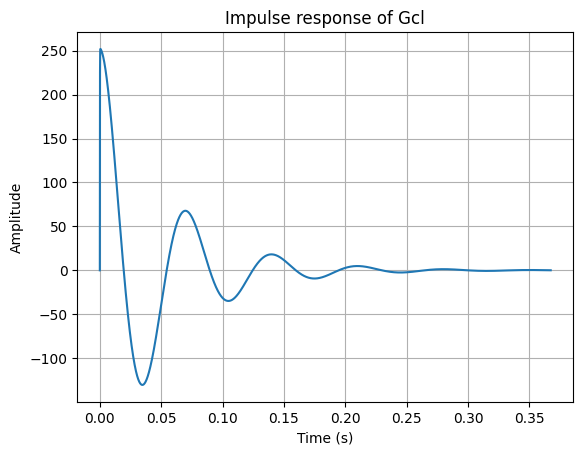

In [ ]:
t_imp, x_imp = ctrl.impulse_response(Gcl)

plt.plot(t_imp, x_imp)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Impulse response of Gcl')
plt.grid()
plt.show()

system output to step response

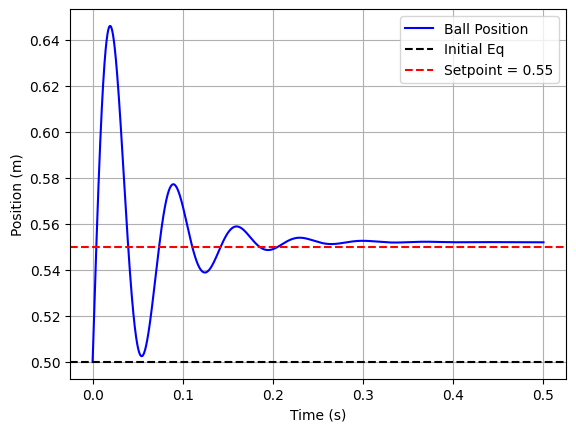

In [ ]:
#5cm setpoint change (from 0.5m to 0.55m)
t_span = np.linspace(0, 0.5, 2000)
t, pos = ctrl.step_response(Gcl * 0.05, t_span)

plt.plot(t, pos + 0.5, 'b', label="Ball Position") #need to add +0.5 because Gcl assumes equilibirum so pos = 0
plt.axhline(0.5, color='k', linestyle='--', label="Initial Eq")
plt.axhline(0.55, color='r', linestyle='--', label="Setpoint = 0.55")

plt.ylabel("Position (m)")
plt.xlabel("Time (s)")
plt.legend()
plt.grid()
plt.show()

Non-linear simulation of controller

Equilibrium: x = 0.5 m, i = 0.6988 A, V = 1537.39 V


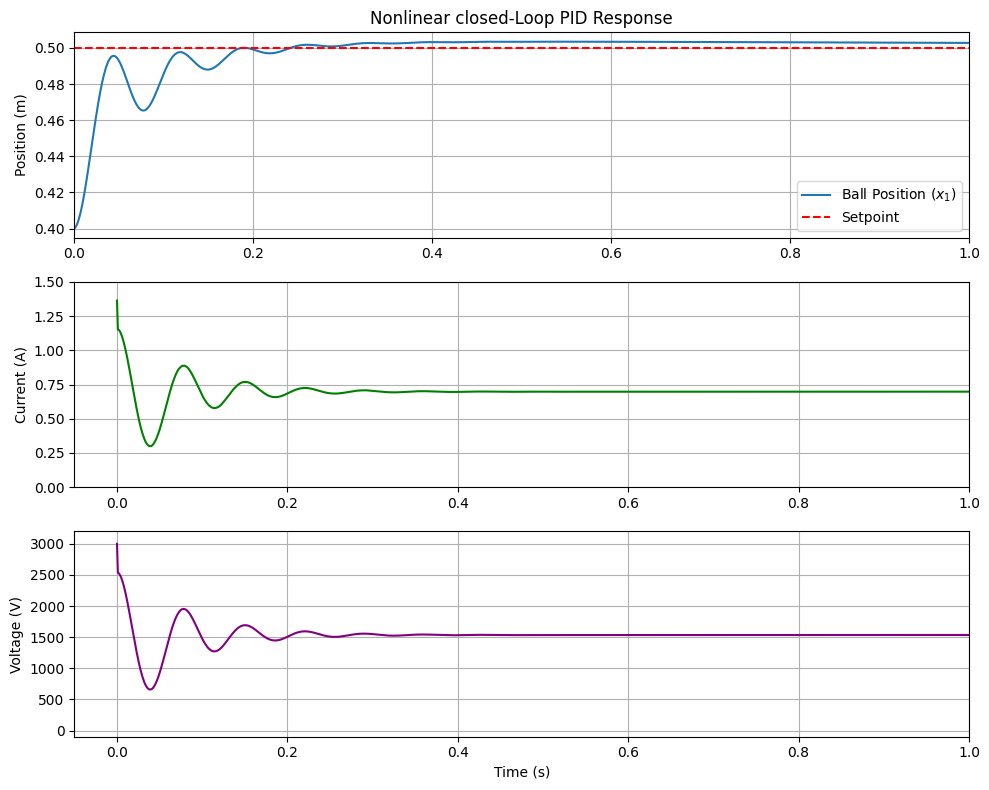

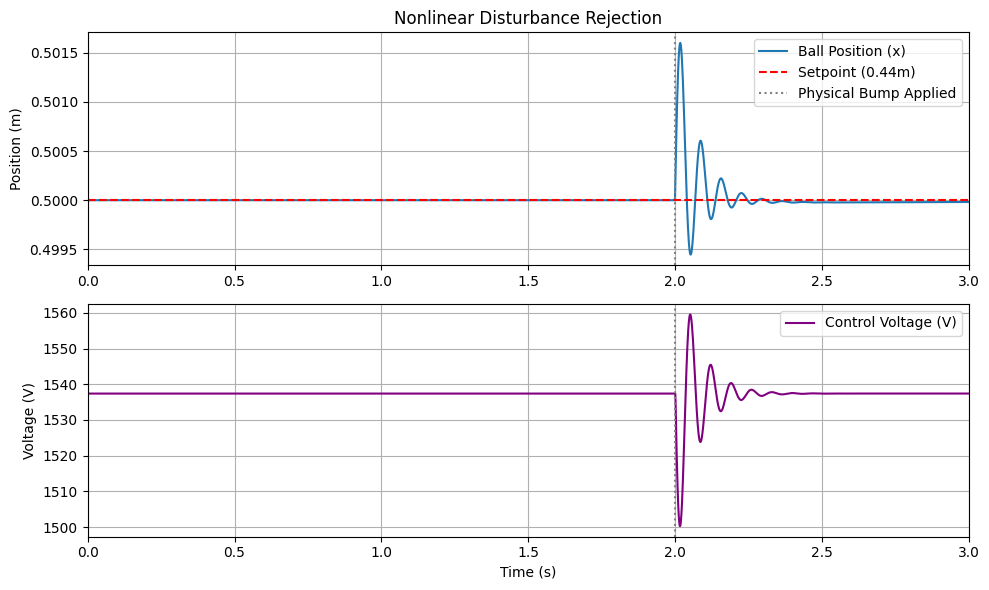

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import StateSpace, lsim, TransferFunction

# 1. System Parameters
m = 0.462
g = 9.81
r = 0.123
k = 1885.0
b = 10.4
d = 0.42
delta = 0.65
phi = np.deg2rad(41) # 41 degrees
R = 2200.0
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c = 6.811       # Magnetic constant
tau_m = 0.03    # Sensor time constant
Km = 1.0        # Sensor (DC) gain

# Derived effective mass for a rolling sphere
m_eff = (7/5) * m

# 2. Operating Point / Equilibrium
x_sp = 0.5     # Setpoint position (m)
# Mechanical equilibrium to find i_eq
# F_mag = mg*sin(phi) + k(x - d)
f_grav_spring = k*(x_sp - d) - m*g*np.sin(phi)
i_eq = np.sqrt(f_grav_spring * (delta - x_sp)**2 / c)
V_eq = R * i_eq # Voltage at equilibrium

print(f"Equilibrium: x = {x_sp} m, i = {i_eq:.4f} A, V = {V_eq:.2f} V")

# 3. Nonlinear System ODEs
def system_dynamics(t, state, u):

    x1, x2, x3, x4 = state

    # Distance from electromagnet (y = delta - x1)
    y = delta - x1

    # Magnetic force: c * (current)^2 / (distance)^2
    f_mag = c * x3**2 / y**2

    # State 1 Derivative (Velocity)
    x1_dot = x2

    # State 2 Derivative (Acceleration / Newton's 2nd Law)
    x2_dot = (m*g*np.sin(phi) - k*(x1 - d) - b*x2 + f_mag) / m_eff

    # State 3 Derivative (Electrical ODE)
    Lx = L0 + L1 * np.exp(-alpha * y)
    dLdx = L1 * alpha * np.exp(-alpha * y)
    x3_dot = (u - R*x3 - x3 * dLdx * x2) / Lx

    # State 4 Derivative (Sensor ODE)
    x4_dot = (Km * x1 - x4) / tau_m

    # Return the derivatives in the exact same order
    return [x1_dot, x2_dot, x3_dot, x4_dot]

# 4. PID Controller Implementation
# Based on design requirements: OS < 10%, Settling < 2s
Kp = 10000.0
Ki = 5000
Kd = 850.0

# By implementing a time-step loop, we can actively compute a new control
# voltage (V_control) at every millisecond using this pid_control function
def pid_control(t, state, integral_error, last_error):
    x = state[3]
    error = x_sp - x
    dt = 0.001 # Approximation for derivative

    prop = Kp * error
    integ = Ki * (integral_error + error * dt)
    deriv = Kd * (error - last_error) / dt

    V_control = V_eq + prop + integ + deriv
    return np.clip(V_control, 0, 3000), error # Clip to realistic voltage

# 5. Revised Simulation Loop with PID
dt = 0.001
t_final = 5
time_steps = np.arange(0, t_final, dt)

# Initialize tracking variables
integral_error = 0
last_error = 0
current_state = [0.40, 0, i_eq, 0.40]
              # [actual_x, velocity, current, measured_x]

# Storage for plotting
history_t = []
history_x1 = [] # Position
history_x2 = [] # Velocity
history_x3 = [] # Current
history_u = []  # COntrol Voltage

for t in time_steps:

    # 1. Read the sensor (State variable x4)
    current_measured_x = current_state[3]

    # 2. Calculate the PID Error terms
    error = x_sp - current_measured_x
    integral_error += error * dt
    derivative_error = (error - last_error) / dt

    # 3. Calculate PID Output
    pid_output = Kp * error + Ki * integral_error + Kd * derivative_error

    # 4. Calculate the total control voltage (Equilibrium + PID adjustment)
    u = V_eq + pid_output

    # 5. Clip the voltage to match real-world power supply limits
    u = np.clip(u, -100, 3000)

    # 6. Run the simulation for this millisecond using u
    sol = solve_ivp(system_dynamics, [t, t + dt], current_state, args=(u,))

    # 2. Update error terms for next iteration
    last_error = error
    current_state = sol.y[:, -1]

    # 4. Save results and update current state
    history_t.append(t)
    history_x1.append(current_state[0])
    history_x2.append(current_state[1])
    history_x3.append(current_state[2])
    history_u.append(u)

# Convert to arrays for plotting
history_t = np.array(history_t)
history_x1 = np.array(history_x1)
history_x2 = np.array(history_x2)
history_x3 = np.array(history_x3)
history_u = np.array(history_u)

# 6. Plotting Results
plt.figure(figsize=(10, 8))

# Position Plot
plt.subplot(3, 1, 1)
plt.plot(history_t, history_x1, label='Ball Position ($x_1$)')
plt.axhline(y=x_sp, color='r', linestyle='--', label='Setpoint')
plt.ylabel('Position (m)')
plt.title('Nonlinear closed-Loop PID Response')
plt.xlim(0, 1.0)
plt.legend(loc = 'lower right'); plt.grid(True)

# Current Plot
plt.subplot(3, 1, 2)
plt.plot(history_t, history_x3, color='green', label='Current ($x_3$)')
plt.ylabel('Current (A)')
plt.xlim(-0.05, 1.0)
plt.ylim(0, 1.5)
plt.grid(True)

# Control Voltage Plot (Important to check for saturation)
plt.subplot(3, 1, 3)
plt.plot(history_t, history_u, color='purple', label='Control Voltage ($u$)')
plt.ylabel('Voltage (V)')
plt.xlabel('Time (s)')
plt.xlim(-0.05, 1.0)
plt.ylim(-100, 3200)
plt.grid(True)

plt.tight_layout()
plt.savefig('nonlinear_response.png', dpi=300, bbox_inches='tight')
plt.show()


# 7. Disturbance Rejection Test
# Run for 4 seconds.
t_final_dist = 4.0
time_steps_dist = np.arange(0, t_final_dist, dt)

# Start already settled AT the setpoint (0.44m) and at equilibrium current
current_state = [x_sp, 0, i_eq, x_sp]
integral_error = 0
last_error = 0

history_t_dist = []
history_x_dist = []
history_v_dist = []

for t in time_steps_dist:
    # INJECT DISTURBANCE: At exactly t = 2.0s, give the ball a sudden physical bump
    # This instantly changes its velocity by 0.15 m/s down the ramp
    if abs(t - 2.0) < dt/2:
        current_state[1] += 0.15

    # 1. Calculate PID control voltage
    v_out, error = pid_control(t, current_state, integral_error, last_error)

    # 2. Update error terms
    integral_error += error * dt
    last_error = error

    # 3. Simulate one step
    sol = solve_ivp(system_dynamics, [t, t + dt], current_state, args=(v_out,))

    # 4. Save results
    current_state = sol.y[:, -1]
    history_t_dist.append(t)
    history_x_dist.append(current_state[0])
    history_v_dist.append(v_out)

# Plotting the Disturbance Rejection
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(history_t_dist, history_x_dist, label='Ball Position (x)')
plt.axhline(y=x_sp, color='r', linestyle='--', label='Setpoint (0.44m)')
plt.axvline(x=2.0, color='grey', linestyle=':', label='Physical Bump Applied')
plt.ylabel('Position (m)')
plt.title('Nonlinear Disturbance Rejection')
plt.legend()
plt.xlim(0, 3)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(history_t_dist, history_v_dist, color='purple', label='Control Voltage (V)')
plt.axvline(x=2.0, color='grey', linestyle=':')
plt.ylabel('Voltage (V)')
plt.xlabel('Time (s)')
plt.legend()
plt.xlim(0, 3)
plt.grid(True)

plt.tight_layout()
plt.savefig('nonlinear_disturbance_response.png', dpi=300, bbox_inches='tight')
plt.show()


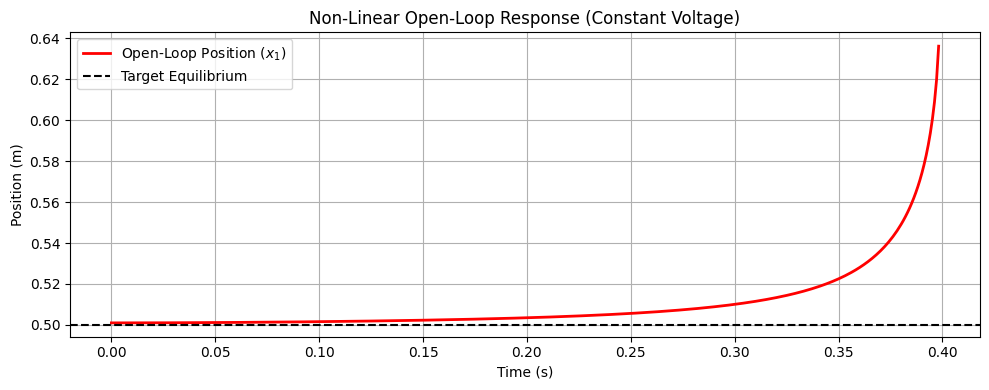

In [ ]:
# ==========================================
# OPEN-LOOP SIMULATION
# ==========================================
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. For open-loop, we turn off the PID and apply a strictly constant voltage.
u_open_loop = V_eq

# 2. Start the ball EXACTLY at equilibrium, but add a small
# 1mm disturbance (0.001m) to see if the system can naturally recover.
initial_state_ol = [x_sp + 0.001, 0.0, i_eq, x_sp + 0.001]

# 3. Run the physics non-stop (no 'for' loop needed because voltage is constant)
sol_ol = solve_ivp(system_dynamics,
                   [0, 2.0], # Simulate for 2 seconds
                   initial_state_ol,
                   t_eval=np.linspace(0, 2.0, 2000),
                   args=(u_open_loop,))

# 4. Extract the results
history_t_ol = sol_ol.t
history_x1_ol = sol_ol.y[0]

# ==========================================
# PLOTTING
# ==========================================
plt.figure(figsize=(10, 4))
plt.plot(history_t_ol, history_x1_ol, color='red', linewidth=2, label='Open-Loop Position ($x_1$)')
plt.axhline(y=x_sp, color='k', linestyle='--', label='Target Equilibrium')

plt.ylabel('Position (m)')
plt.xlabel('Time (s)')
plt.title('Non-Linear Open-Loop Response (Constant Voltage)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.signal import StateSpace

# 1. Calculate the specific matrix components from handwritten notes

x_sp_values = [0.44, 0.49, 0.5]

for x_sp in x_sp_values:
      f_grav_spring = k*(x_sp - d) - m*g*np.sin(phi)
      i_sp = np.sqrt(f_grav_spring * (delta - x_sp)**2 / c)

      print(f"Operating Point: x_sp = {x_sp} m, i_sp = {i_sp:.4f} A")

      L_sp = L0 + L1 * np.exp(-alpha * (delta - x_sp))

      a21 = (5 / (7 * m)) * ((2 * c * i_sp**2) / (delta - x_sp)**3 - k)
      a22 = - (5 * b) / (7 * m)
      a23 = (5 / (7 * m)) * ((2 * c * i_sp) / (delta - x_sp)**2)

      a33 = - R / L_sp
      a41 = Km / tau_m
      a44 = - 1 / tau_m

      # 2. Build the Matrices (A, B, C, D)
      A = np.array([
          [0,     1,   0,   0],
          [a21, a22, a23,   0],
          [0,     0, a33,   0],
          [a41,   0,   0, a44]
      ])

      B = np.array([
          [0],
          [0],
          [1 / L_sp],
          [0]
      ])

      # C matrix defines the output (we want the 4th state, x_m)
      C = np.array([[0, 0, 0, 1]])

      # D matrix is zero (no direct feedthrough from voltage to sensor)
      D = np.array([[0]])

      # 3. Create the Linear State-Space System
      linear_sys = StateSpace(A, B, C, D)

      # 4. Prove Stability by calculating the poles
      poles = linear_sys.poles

      print("System Poles:")
      for i, pole in enumerate(poles):
          # Format the poles to 4 decimal places
          if np.iscomplex(pole):
              print(f"  λ{i+1} = {np.real(pole):.4f} ± {np.abs(np.imag(pole)):.4f}j")
          else:
              print(f"  λ{i+1} = {np.real(pole):.4f}")

      print("\n") # Add a blank line between runs for readability

Operating Point: x_sp = 0.44 m, i_sp = 0.4742 A
System Poles:
  λ1 = -15306.3072
  λ2 = -8.0396 ± 48.3568j
  λ3 = -8.0396 ± 48.3568j
  λ4 = -33.3333


Operating Point: x_sp = 0.49 m, i_sp = 0.6963 A
System Poles:
  λ1 = -15183.9436
  λ2 = -33.3333
  λ3 = -8.0396 ± 18.8977j
  λ4 = -8.0396 ± 18.8977j


Operating Point: x_sp = 0.5 m, i_sp = 0.6988 A
System Poles:
  λ1 = -15158.8219
  λ2 = -33.3333
  λ3 = -22.0977
  λ4 = 6.0185




/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


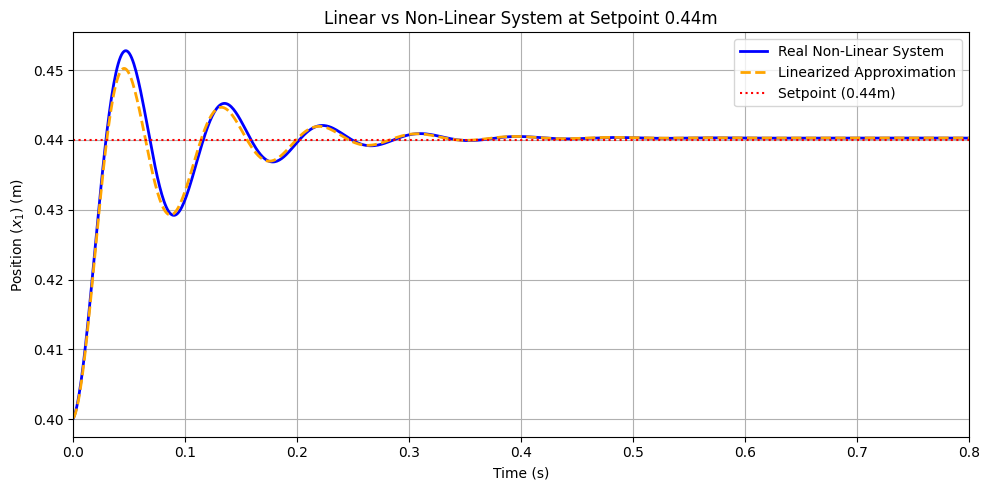

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

x_sp = 0.44  # Target Setpoint
start_x = x_sp - 0.04 # Drop from 0.40m

f_grav_spring = k*(x_sp - d) - m*g*np.sin(phi)
i_eq = np.sqrt(f_grav_spring * (delta - x_sp)**2 / c)
Lx_eq = L0 + L1 * np.exp(-alpha * (delta - x_sp))
V_eq = i_eq * R

a21 = (5 / (7 * m)) * ((2 * c * i_eq**2) / (delta - x_sp)**3 - k)
a22 = - (5 * b) / (7 * m)
a23 = (5 / (7 * m)) * ((2 * c * i_eq) / (delta - x_sp)**2)
a33 = - R / Lx_eq
a41 = Km / tau_m
a44 = - 1 / tau_m

A = np.array([[0, 1, 0, 0], [a21, a22, a23, 0], [0, 0, a33, 0], [a41, 0, 0, a44]])
B = np.array([[0], [0], [1 / Lx_eq], [0]])

def linear_dynamics(t, state_delta, V_input):
    delta_V = V_input - V_eq
    return A.dot(state_delta) + B.dot([delta_V]).flatten()

# Non-Linear Tracking
current_state = [start_x, 0, i_eq, start_x]
history_x1 = []
integral_error = 0
last_error = 0

# Linear Tracking
current_state_delta = [start_x - x_sp, 0, 0, start_x - x_sp]
history_x_lin = []
integral_error_lin = 0
last_error_lin = 0

history_t_sync = []

for t in time_steps:
    # --- Simulate Real Non-Linear System ---
    measured_x = current_state[3]
    error = x_sp - measured_x
    integral_error += error * dt
    deriv = (error - last_error) / dt

    u = V_eq + Kp * error + Ki * integral_error + Kd * deriv
    u = np.clip(u, -100, 3000)

    sol = solve_ivp(system_dynamics, [t, t + dt], current_state, args=(u,))
    current_state = sol.y[:, -1]
    last_error = error
    history_x1.append(current_state[0])

    # --- Simulate Linearised System ---
    measured_x_lin = current_state_delta[3] + x_sp
    error_lin = x_sp - measured_x_lin
    integral_error_lin += error_lin * dt
    deriv_lin = (error_lin - last_error_lin) / dt

    V_control = V_eq + Kp * error_lin + Ki * integral_error_lin + Kd * deriv_lin
    V_control = np.clip(V_control, -100, 3000)

    sol_lin = solve_ivp(linear_dynamics, [t, t + dt], current_state_delta, args=(V_control,))
    current_state_delta = sol_lin.y[:, -1]
    last_error_lin = error_lin
    history_x_lin.append(current_state_delta[0] + x_sp)

    # Track time
    history_t_sync.append(t)

plt.figure(figsize=(10, 5))
plt.plot(history_t_sync, history_x1, label='Real Non-Linear System', color='blue', linewidth=2)
plt.plot(history_t_sync, history_x_lin, label='Linearized Approximation', color='orange', linestyle='--', linewidth=2)
plt.axhline(y=x_sp, color='r', linestyle=':', label=f'Setpoint ({x_sp}m)')

plt.ylabel('Position ($x_1$) (m)')
plt.xlabel('Time (s)')
plt.xlim(0, 0.8)
plt.title(f'Linear vs Non-Linear System at Setpoint {x_sp}m')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

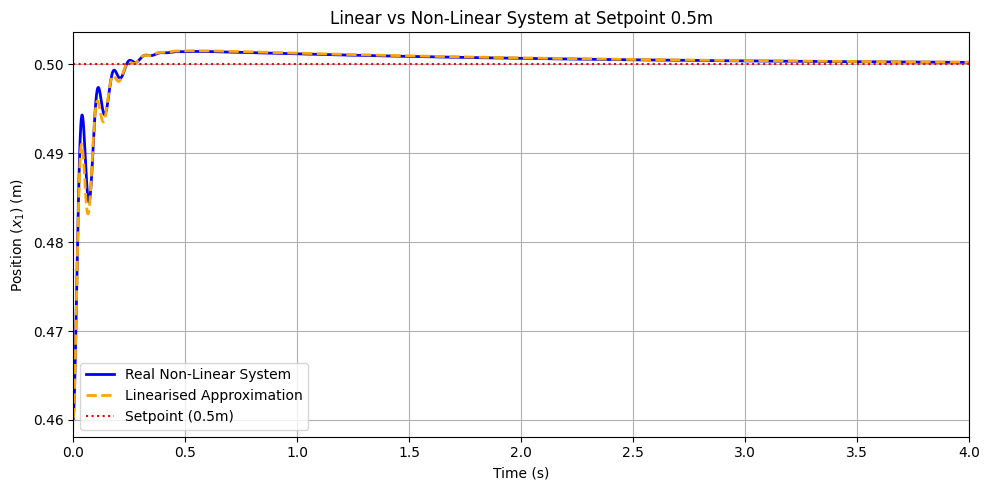

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

x_sp = 0.5  # Target Setpoint
start_x = x_sp - 0.04
t_sim = 4.0         # Force simulation to 4 seconds
dt = 0.001
time_steps = np.arange(0, t_sim, dt)

f_grav_spring = k*(x_sp - d) - m*g*np.sin(phi)
i_eq = np.sqrt(f_grav_spring * (delta - x_sp)**2 / c)
Lx_eq = L0 + L1 * np.exp(-alpha * (delta - x_sp))
V_eq = i_eq * R

a21 = (5 / (7 * m)) * ((2 * c * i_eq**2) / (delta - x_sp)**3 - k)
a22 = - (5 * b) / (7 * m)
a23 = (5 / (7 * m)) * ((2 * c * i_eq) / (delta - x_sp)**2)
a33 = - R / Lx_eq
a41 = Km / tau_m
a44 = - 1 / tau_m

A = np.array([[0, 1, 0, 0], [a21, a22, a23, 0], [0, 0, a33, 0], [a41, 0, 0, a44]])
B = np.array([[0], [0], [1 / Lx_eq], [0]])

def linear_dynamics(t, state_delta, V_input):
    delta_V = V_input - V_eq
    return A.dot(state_delta) + B.dot([delta_V]).flatten()

# Non-Linear Tracking
current_state = [start_x, 0, i_eq, start_x]
history_x1 = []
integral_error = 0
last_error = 0

# Linear Tracking
current_state_delta = [start_x - x_sp, 0, 0, start_x - x_sp]
history_x_lin = []
integral_error_lin = 0
last_error_lin = 0

history_t_sync = []

for t in time_steps:
    # --- Simulate Real Non-Linear System ---
    measured_x = current_state[3]
    error = x_sp - measured_x
    integral_error += error * dt
    deriv = (error - last_error) / dt

    u = V_eq + Kp * error + Ki * integral_error + Kd * deriv
    u = np.clip(u, -100, 3000)

    sol = solve_ivp(system_dynamics, [t, t + dt], current_state, args=(u,))
    current_state = sol.y[:, -1]
    last_error = error
    history_x1.append(current_state[0])

    # --- Simulate Linearised System ---
    measured_x_lin = current_state_delta[3] + x_sp
    error_lin = x_sp - measured_x_lin
    integral_error_lin += error_lin * dt
    deriv_lin = (error_lin - last_error_lin) / dt

    V_control = V_eq + Kp * error_lin + Ki * integral_error_lin + Kd * deriv_lin
    V_control = np.clip(V_control, -100, 3000)

    sol_lin = solve_ivp(linear_dynamics, [t, t + dt], current_state_delta, args=(V_control,))
    current_state_delta = sol_lin.y[:, -1]
    last_error_lin = error_lin
    history_x_lin.append(current_state_delta[0] + x_sp)

    # Track time
    history_t_sync.append(t)

plt.figure(figsize=(10, 5))
plt.plot(history_t_sync, history_x1, label='Real Non-Linear System', color='blue', linewidth=2)
plt.plot(history_t_sync, history_x_lin, label='Linearised Approximation', color='orange', linestyle='--', linewidth=2)
plt.axhline(y=x_sp, color='r', linestyle=':', label=f'Setpoint ({x_sp}m)')

plt.ylabel('Position ($x_1$) (m)')
plt.xlabel('Time (s)')
plt.xlim(0, t_sim)
plt.title(f'Linear vs Non-Linear System at Setpoint {x_sp}m')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()